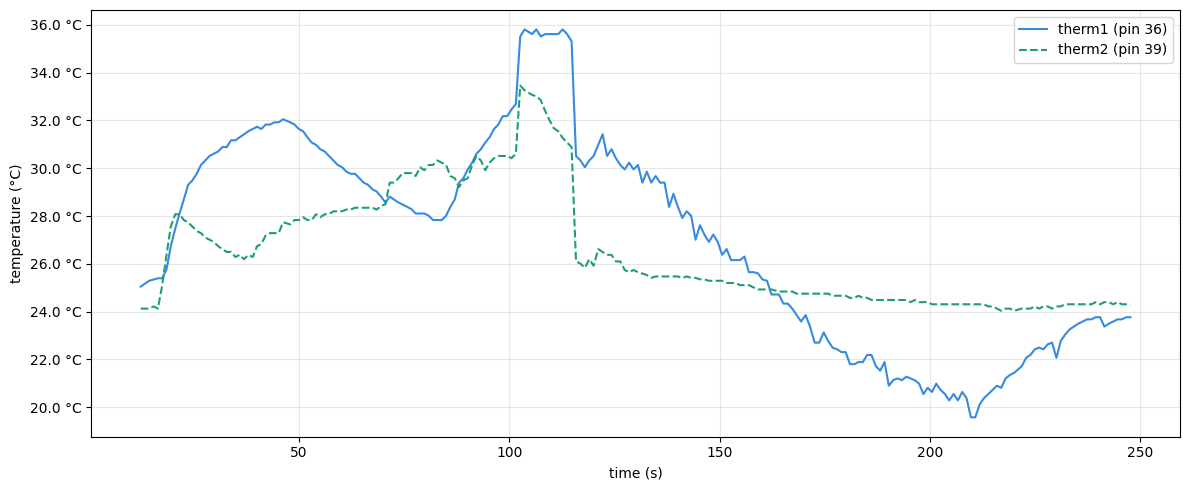

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

df = pd.read_csv('temps.txt')
df['time_s'] = df['timestamp_ms'] / 1000

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df['time_s'], df['temp1_C'], label='therm1 (pin 36)', linewidth=1.5, color='#378ADD')
ax.plot(df['time_s'], df['temp2_C'], label='therm2 (pin 39)', linewidth=1.5, color='#1D9E75', linestyle='--')

ax.set_xlabel('time (s)')
ax.set_ylabel('temperature (°C)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f °C'))

plt.tight_layout()
plt.savefig('temps.png', dpi=150)
plt.show()

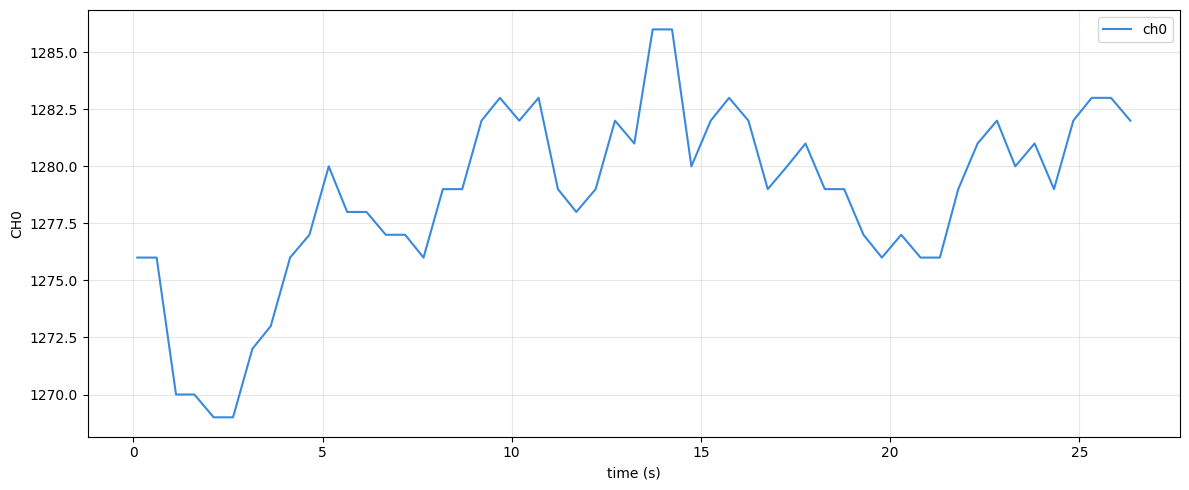

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

df = pd.read_csv('Calibration Output2.txt')
df['time_s'] = df['time_ms'] / 1000

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df['time_s'], df['ch0'], label='ch0', linewidth=1.5, color='#378ADD')

ax.set_xlabel('time (s)')
ax.set_ylabel('CH0')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('temps.png', dpi=150)
plt.show()

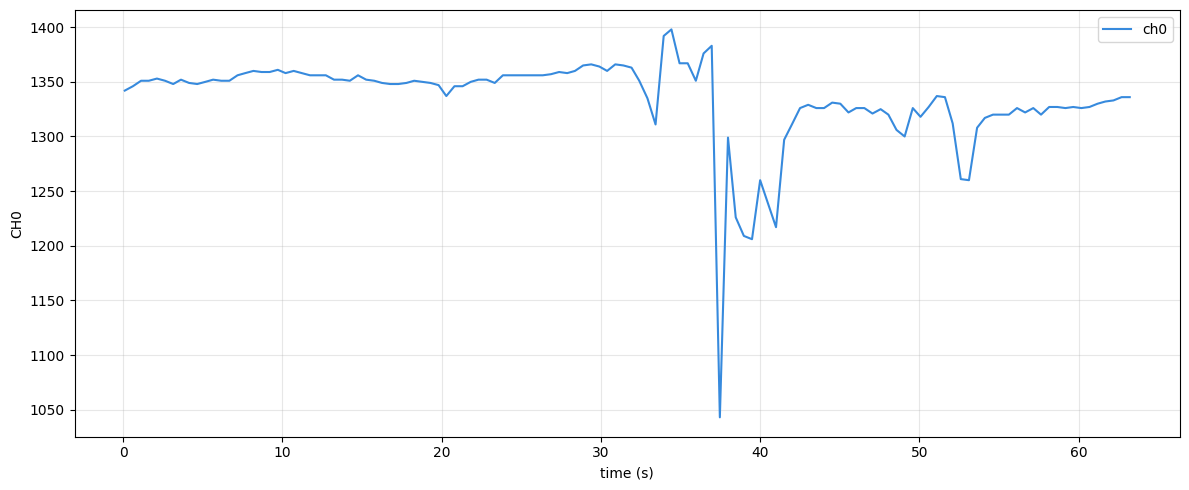

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

df = pd.read_csv('Calibration Output3.txt')
df['time_s'] = df['time_ms'] / 1000

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df['time_s'], df['ch0'], label='ch0', linewidth=1.5, color='#378ADD')

ax.set_xlabel('time (s)')
ax.set_ylabel('CH0')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('temps.png', dpi=150)
plt.show()

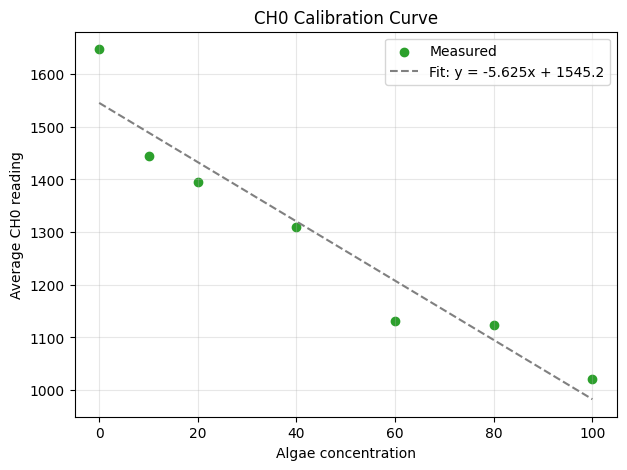

{0: np.float64(1647.1690140845071), 10: np.float64(1443.9264705882354), 20: np.float64(1394.8714285714286), 40: np.float64(1310.030303030303), 60: np.float64(1131.030303030303), 80: np.float64(1123.8214285714287), 100: np.float64(1021.981308411215)}


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

concentrations = [0, 10, 20, 40, 60, 80, 100]
avg_ch0 = []

for i in range(1, 8):
    filename = f"Calibration Output1-{i}.txt"
    df = pd.read_csv(filename)
    avg_ch0.append(df['ch0'].mean())

coeffs = np.polyfit(concentrations, avg_ch0, 1)
fit_line = np.polyval(coeffs, concentrations)

plt.figure(figsize=(7, 5))
plt.scatter(concentrations, avg_ch0, color='tab:green', label='Measured')
plt.plot(concentrations, fit_line, '--', color='gray',
         label=f'Fit: y = {coeffs[0]:.3f}x + {coeffs[1]:.1f}')
plt.xlabel('Algae concentration')
plt.ylabel('Average CH0 reading')
plt.title('CH0 Calibration Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(dict(zip(concentrations, avg_ch0)))